In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# read
train = pd.read_csv('../data/Task1/train.csv')

In [ ]:
# view
train

In [28]:
train.info()
train.describe()

<class 'pandas.DataFrame'>
Index: 244089 entries, 97877 to 278392
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               244089 non-null  float64
 1   high               244089 non-null  float64
 2   low                244089 non-null  float64
 3   momentum_index     244089 non-null  float64
 4   beta_indicator     244089 non-null  float64
 5   risk_premium       244089 non-null  float64
 6   volatility_factor  244089 non-null  float64
 7   technical_score    244089 non-null  float64
 8   oscillator_value   244089 non-null  float64
 9   liquidity_ratio    244089 non-null  float64
 10  open               244089 non-null  float64
 11  quant_index        244089 non-null  float64
 12  trend_strength     244089 non-null  float64
 13  market_sentiment   244089 non-null  float64
 14  close              244089 non-null  float64
 15  volume             244089 non-null  float64
 16  alpha_signal  

,date,high,low,momentum_index,beta_indicator,risk_premium,volatility_factor,technical_score,oscillator_value,liquidity_ratio,open,quant_index,trend_strength,market_sentiment,close,volume,alpha_signal,symbols_Low,symbols_MRO,symbols_ULTA
count,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,2.440890e+05,244089.000000,244089.000000
mean,1.102395e-16,1.676735e-17,3.446622e-17,6.893245e-17,4.337388e-17,4.448006e-17,4.069576e-17,4.937054e-17,4.203482e-17,1.164399e-18,3.260318e-18,-9.256976e-17,-8.016890e-17,4.191838e-18,9.885751e-17,-6.520637e-17,4.482938e-17,1.991123e-17,0.250761,0.250761
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.433452,0.433452
min,-1.755892e+00,-1.995174e+00,-2.053768e+00,-2.697532e+00,-2.065076e+00,-2.222602e+00,-2.683945e+00,-2.682921e+00,-2.138520e+00,-2.025248e+00,-1.945438e+00,-2.699658e+00,-2.691114e+00,-2.254955e+00,-8.610289e-01,-6.279799e-01,-2.698000e+00,-5.739414e-01,0.000000,0.000000
25%,-8.638794e-01,-6.602238e-01,-6.622192e-01,-6.764665e-01,-6.700150e-01,-6.784358e-01,-6.740576e-01,-6.756137e-01,-6.679853e-01,-6.681374e-01,-6.493203e-01,-6.738808e-01,-6.755150e-01,-6.838569e-01,-4.467321e-01,-4.959438e-01,-6.834803e-01,-5.739414e-01,0.000000,0.000000
50%,1.457707e-02,-8.494235e-02,-7.777320e-02,-1.208537e-02,-7.033758e-02,-3.904483e-02,-1.250806e-02,-1.517190e-02,-5.774481e-02,-7.818139e-02,-9.828168e-02,4.214444e-03,-8.392691e-03,-2.993535e-02,-2.171731e-01,-3.285914e-01,-1.546574e-02,-5.739414e-01,0.000000,0.000000
75%,8.686320e-01,5.272755e-01,5.525065e-01,6.709102e-01,5.627887e-01,6.276297e-01,6.658672e-01,6.625911e-01,5.891514e-01,5.462774e-01,5.098194e-01,6.766374e-01,6.682179e-01,6.438036e-01,1.364754e-01,3.742860e-02,6.595328e-01,-5.739414e-01,1.000000,1.000000
max,1.703708e+00,4.018694e+00,3.810324e+00,2.691975e+00,3.713252e+00,3.019112e+00,2.675755e+00,2.669898e+00,3.464514e+00,3.885483e+00,4.174180e+00,2.702415e+00,2.683817e+00,2.814291e+00,2.012819e+01,5.941524e+00,2.674052e+00,1.742331e+00,1.000000,1.000000


# Preprocess

In [4]:
train.sort_values('index', inplace=True)
train.drop(columns='index', inplace=True)

In [5]:
# drop duplicates
print(train.duplicated().sum())
train.drop_duplicates(inplace=True)

train.isna().sum() / train.index.size * 100
# barely any missing so simply dropping
train.dropna(inplace=True)
train = train[train.date != '0']

20969


In [6]:
train.date = pd.to_datetime(train.date)
# replace raw date by time elapsed from the earliest date
min_date = train.date.min() # will need for testing
train.date = (train.date - min_date).dt.total_seconds()

In [7]:
train.symbols.value_counts()
# one-hot encoding of symbols
train = pd.get_dummies(train, columns=['symbols'], drop_first=True, dtype=int)

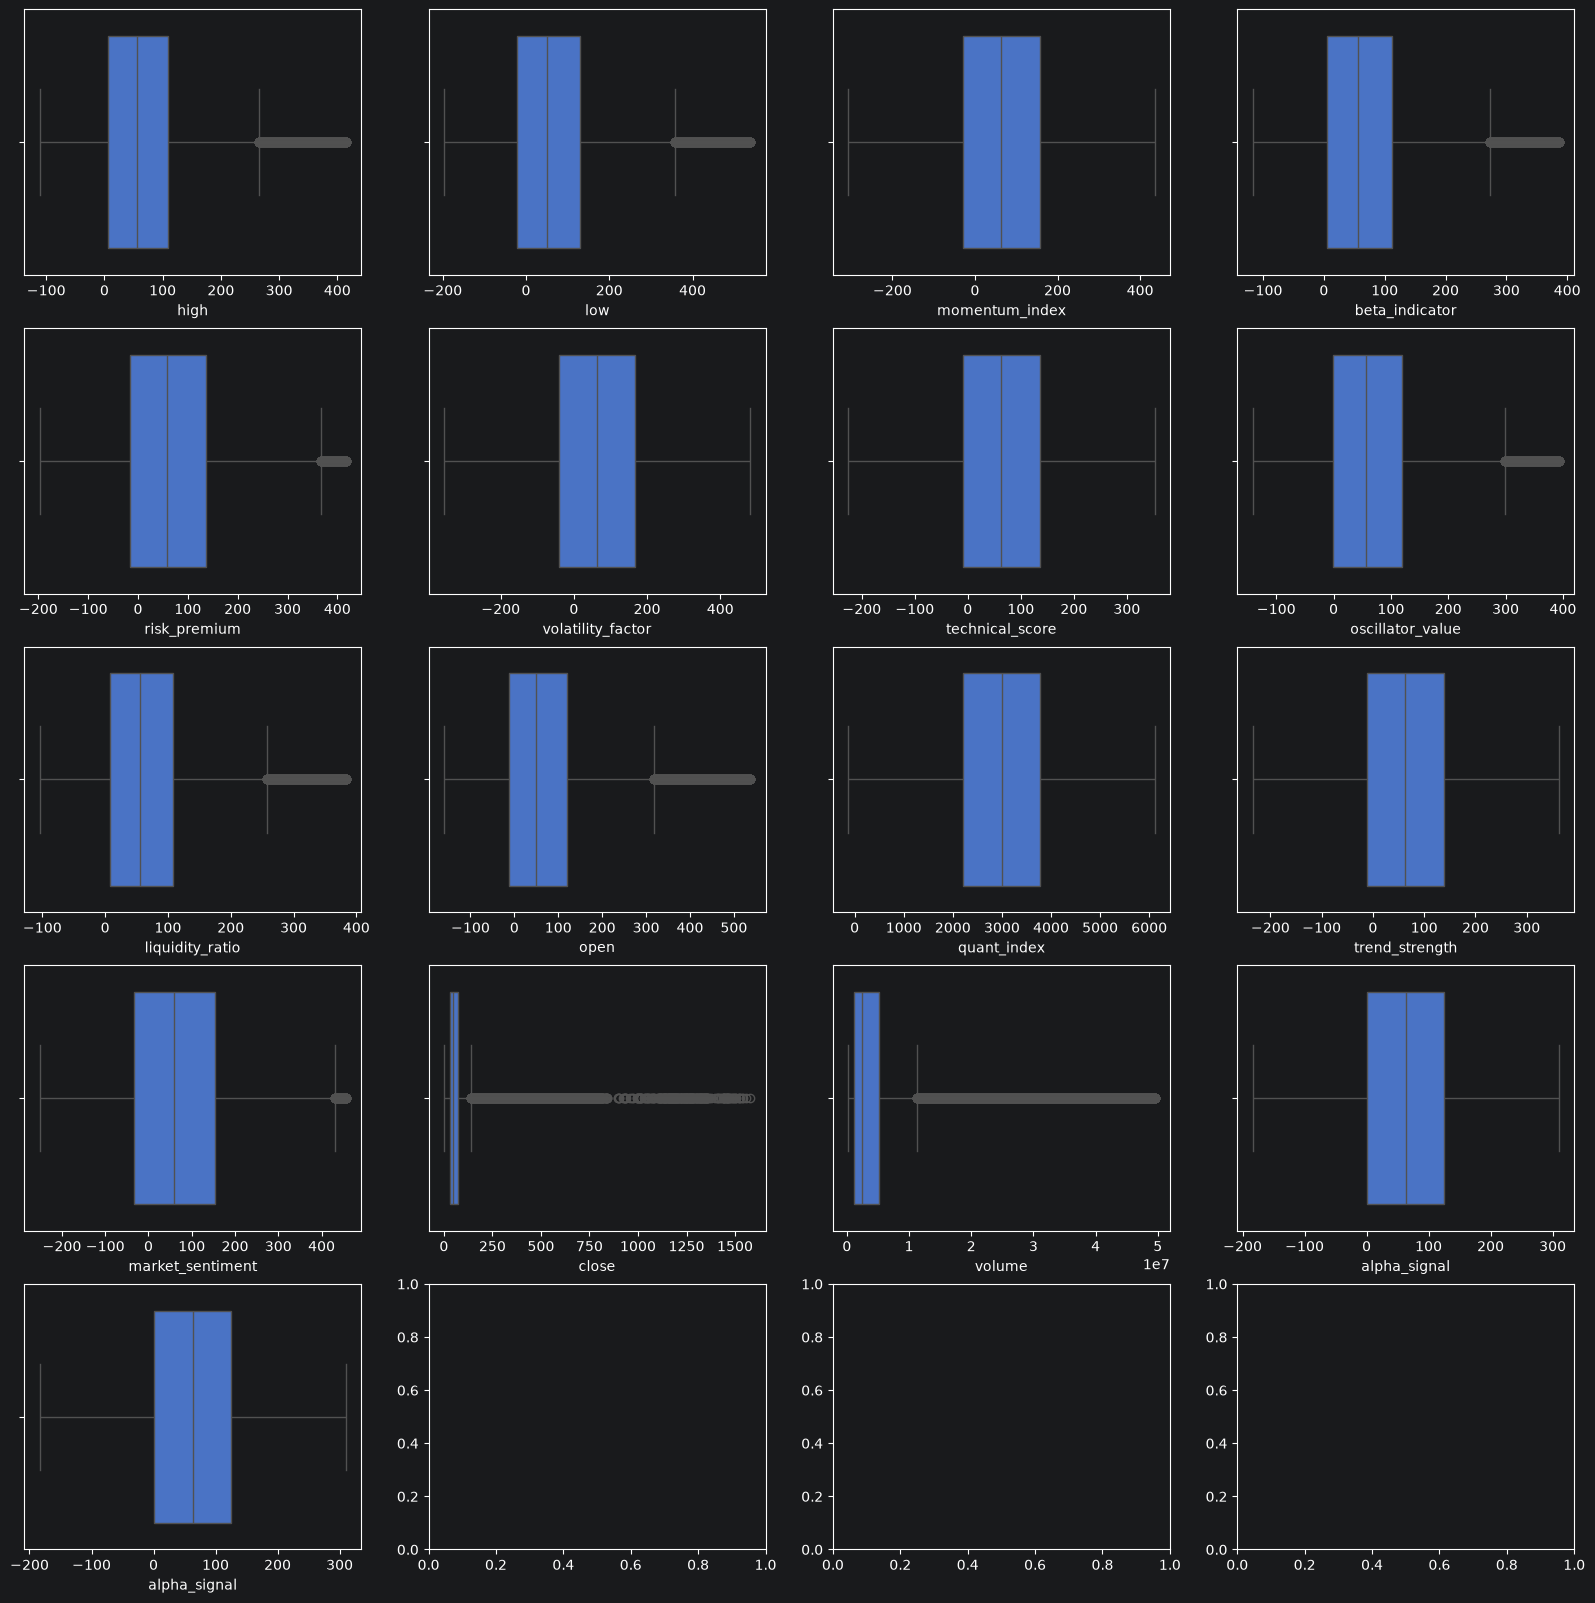

In [10]:
# boxplot to detect outliers
fig, ax = plt.subplots(5, 4, figsize=(20, 20))
for i in range(0, 4):
    sns.boxplot(x=train.iloc[:,i*4+1], ax=ax[i][0])
    sns.boxplot(x=train.iloc[:,i*4+2], ax=ax[i][1])
    sns.boxplot(x=train.iloc[:,i*4+3], ax=ax[i][2])
    sns.boxplot(x=train.iloc[:,i*4+4], ax=ax[i][3])
sns.boxplot(x=train.alpha_signal, ax=ax[4][0])
plt.show()

In [9]:
# outlier treatment
for feature in ['high', 'low', 'beta_indicator', 'risk_premium', 'oscillator_value', 'liquidity_ratio', 'open', 'market_sentiment', 'volume']:
    train[feature] = np.clip(train[feature], *np.percentile(train[feature], [1, 99]))
for feature in ['momentum_index', 'volatility_factor', 'technical_score', 'quant_index', 'trend_strength', 'alpha_signal']:
    q1, q3 = np.percentile(train[feature], [25, 75])
    iqr = q3 - q1
    train[feature] = np.clip(train[feature], q1 - iqr*1.5, q3 + iqr*1.5)

In [11]:
# reserve stats
y_mean, y_std = np.mean(train.close), np.std(train.close)
means = train.describe().T['mean'].iloc[:18]
stds = train.describe().T['std'].iloc[:18]

In [12]:
# feature scaling
def standardize(data, feature):
    data[feature] = (data[feature] - means[feature]) / stds[feature]
for col in train.columns[:18]:
    standardize(train, col)

# Train

In [13]:
def destandardize(y):
    return y * y_std + y_mean

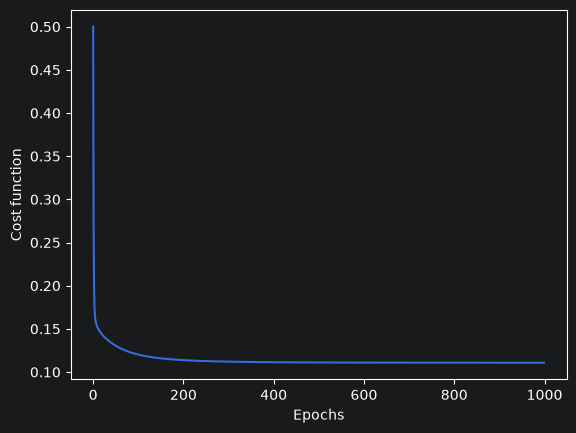

In [14]:
EPOCHS = 1000

x = np.hstack([np.ones((train.index.size, 1)), np.array(train.drop(columns=['close']))])
y = np.array(train[['close']])
weights = np.zeros((x.shape[1], 1))
alpha = 0.1
costs = np.zeros(EPOCHS)
for i in range(EPOCHS):
    hx = x @ weights
    weights -= alpha * (x.T @ (hx - y)) / x.shape[0]
    costs[i] = np.mean((hx-y)**2) / 2

plt.xlabel('Epochs')
plt.ylabel('Cost function')
plt.plot(costs)
plt.show()

# Preprocess Test Dataset

In [15]:
test = pd.read_csv('../data/Task1/test.csv')

In [ ]:
test

In [26]:
test.info()
test.describe()

<class 'pandas.DataFrame'>
Index: 166828 entries, 175636 to 176337
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               166828 non-null  float64
 1   high               166828 non-null  float64
 2   low                166828 non-null  float64
 3   momentum_index     166828 non-null  float64
 4   beta_indicator     166828 non-null  float64
 5   risk_premium       166828 non-null  float64
 6   volatility_factor  166828 non-null  float64
 7   technical_score    166828 non-null  float64
 8   oscillator_value   166828 non-null  float64
 9   liquidity_ratio    166828 non-null  float64
 10  open               166828 non-null  float64
 11  quant_index        166828 non-null  float64
 12  trend_strength     166828 non-null  float64
 13  market_sentiment   166828 non-null  float64
 14  close              166828 non-null  float64
 15  volume             166828 non-null  float64
 16  alpha_signal 

,date,high,low,momentum_index,beta_indicator,risk_premium,volatility_factor,technical_score,oscillator_value,liquidity_ratio,open,quant_index,trend_strength,market_sentiment,close,volume,alpha_signal,symbols_Low,symbols_MRO,symbols_ULTA
count,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000,166828.000000
mean,-0.000327,0.029203,0.027549,0.004287,0.030956,0.018349,0.004953,0.007128,0.024675,0.020845,0.032918,0.007950,0.003324,0.013680,0.003001,0.062546,0.008847,0.411989,0.122222,0.078434
std,1.002523,1.247178,0.792563,0.798631,1.413827,1.550256,0.586108,0.956359,1.489416,2.502602,1.039137,1.003392,1.139733,1.031149,1.001623,1.696808,1.072602,1.145265,0.327543,0.268854
min,-1.755892,-3.118845,-1.713270,-3.369248,-4.858484,-7.152496,-2.278708,-3.919640,-5.618205,-10.103339,-2.525271,-4.779097,-4.879223,-3.758859,-0.861029,-0.657801,-4.421991,-0.573941,0.000000,0.000000
25%,-0.872013,-0.613013,-0.370955,-0.524614,-0.858812,-1.006254,-0.387307,-0.632860,-0.936609,-1.640837,-0.521917,-0.665932,-0.751528,-0.650805,-0.444471,-0.495530,-0.709464,-0.573941,0.000000,0.000000
50%,0.018644,-0.136026,-0.085493,-0.010970,-0.046041,-0.016469,-0.005979,-0.001432,-0.035999,-0.026867,-0.094179,0.009364,-0.016973,-0.028697,-0.216774,-0.329565,-0.006992,-0.573941,0.000000,0.000000
75%,0.868632,0.403077,0.243050,0.508257,0.793533,0.979479,0.379331,0.633760,0.883262,1.605391,0.378324,0.686480,0.727375,0.613968,0.136608,0.034301,0.699081,1.742331,0.000000,0.000000
max,1.703708,23.409707,14.740639,6.983341,17.615660,14.621907,4.946765,6.668973,17.458442,21.986795,18.907259,4.407521,10.338605,12.011786,20.023520,77.905237,8.257000,1.742331,1.000000,1.000000


In [18]:
test.sort_values('index', inplace=True)
test.drop(columns='index', inplace=True)

In [19]:
# reorder columns
test = test[['date', 'high', 'low', 'momentum_index', 'beta_indicator', 'risk_premium', 'volatility_factor', 'technical_score', 'oscillator_value',
             'liquidity_ratio', 'open', 'quant_index', 'trend_strength', 'market_sentiment', 'close', 'volume', 'alpha_signal', 'symbols']]

In [20]:
print(test.duplicated().sum())
test.drop_duplicates(inplace=True)

test.isna().sum() / test.index.size * 100
# barely any missing so simply dropping
test.dropna(inplace=True)
test = test[test.date != '0']

6810


In [21]:
test.date = pd.to_datetime(test.date)
# replace raw date by time elapsed from the earliest date
test.date = (test.date - min_date).dt.total_seconds()   # using train's min_date

In [22]:
test.symbols.value_counts()
# one-hot encoding of symbols
test = pd.get_dummies(test, columns=['symbols'], drop_first=True, dtype=int)

In [23]:
# feature scaling
for col in test.columns[:18]:
    standardize(test, col)

In [24]:
np.all(train.columns == test.columns)   # check feature order

np.True_

# Test

In [29]:
x = np.hstack([np.ones((test.index.size, 1)), np.array(test.drop(columns=['close']))])
y = np.array(test[['close']])

hx = x @ weights
cost = np.mean((hx-y)**2) / 2
print('Cost function for test dataset =', cost)

r2 = 1 - 2 * cost / np.var(y)
print('Coefficient of determination (measure of accuracy) =', r2)

Cost function for test dataset = 0.06712125409751635
Coefficient of determination (measure of accuracy) = 0.8661913886438717


In [30]:
import random

# comparing random predicted and actual labels
idx = np.array([random.randrange(x.shape[0]) for _ in range(100)])
print('Predicted label\t\tActual label')
hx = (x[idx] @ weights)[:,0]
for i in range(100):
    print(f'{destandardize(hx[i]):10.0f}\t\t{destandardize(y[idx[i],0]):10.0f}')

Predicted label		Actual label
        52		        36
       121		        86
        23		        25
        32		        26
        75		        78
        41		        25
        77		        79
        57		        81
       121		       121
         3		        12
        22		        26
        51		        20
        73		        66
        89		       101
         8		        48
        85		       111
         3		        17
        53		        73
       103		        92
        46		        38
        47		        37
        43		        42
        91		        77
        56		        62
        17		        13
        53		        60
        86		        67
        35		        25
        83		        75
        48		        35
        15		        12
        42		        24
        73		        62
        78		        45
        56		        63
        47		        36
        67		        46
        17		        35
        11		        18
        22		        19
        60		        53
       106		        99
    